In [15]:
from glob import glob
from omegaconf import OmegaConf
import pandas as pd
import matplotlib.pyplot as plt

def load(path):
    r = OmegaConf.load(path)
    name = path.split('/')[-2]
    r['name'] = name
    return r

def plot_curves(run_summary):
    epochs = run_summary.curve.epoch
    train = run_summary.curve.train_loss
    val = run_summary.curve.val_loss
    best_epoch = run_summary.best_epoch

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, train, label="train")
    ax.plot(epochs, val, label="val")
    ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    # fig.tight_layout()
    return ax

!pushd ..; ./rsync.sh ; popd
path_list = glob("../out/kfp/*/run_summary.yaml")
len(path_list)

At file://out/kfp/**, worker process 4569 thread 8274942144 listed 174...
At gs://demand-vision/temp/marc/runs/**, worker process 4569 thread 8274942144 listed 186...
Copying gs://demand-vision/temp/marc/runs/lstm_cosine_longer/best_model.pt to file://out/kfp/lstm_cosine_longer/best_model.pt
Copying gs://demand-vision/temp/marc/runs/lstm_cosine_longer/curves.png to file://out/kfp/lstm_cosine_longer/curves.png
Copying gs://demand-vision/temp/marc/runs/lstm_cosine_longer/run_summary.yaml to file://out/kfp/lstm_cosine_longer/run_summary.yaml
Copying gs://demand-vision/temp/marc/runs/lstm_cosine_longer/train.log to file://out/kfp/lstm_cosine_longer/train.log
Copying gs://demand-vision/temp/marc/runs/lstm_cosine_rerun/best_model.pt to file://out/kfp/lstm_cosine_rerun/best_model.pt
Copying gs://demand-vision/temp/marc/runs/lstm_cosine_rerun/curves.png to file://out/kfp/lstm_cosine_rerun/curves.png
Copying gs://demand-vision/temp/marc/runs/lstm_cosine_rerun/run_summary.yaml to file://out/kfp/

37

In [16]:
d = {path.split('/')[-2]: OmegaConf.load(path) for path in path_list} 

In [17]:
df = pd.DataFrame([load(path) for path in path_list])
df = df['name best_val_loss best_epoch max_epochs'.split()]
df = df.set_index('name').sort_values('best_val_loss')
df['iob%'] = 100 * (1 - df['best_val_loss'] / df.loc['baseline', 'best_val_loss'])
df

,best_val_loss,best_epoch,max_epochs,iob%
name,,,,
lstm_cosine,0.090768,8,50,0.409237
lstm_cosine_rerun,0.090768,8,50,0.409237
lstm_cosine_longer,0.090768,8,100,0.409237
lstm_lr001,0.090974,11,50,0.183479
lstm_skip,0.091086,12,50,0.060453
baseline,0.091141,9,50,0.000000
lstm_cosine_t5,0.091328,4,50,-0.204878
lstm_cosine_drop02,0.091473,9,50,-0.364119
lstm_cosine_lr01,0.092068,9,50,-1.017280


<Axes: ylabel='name'>

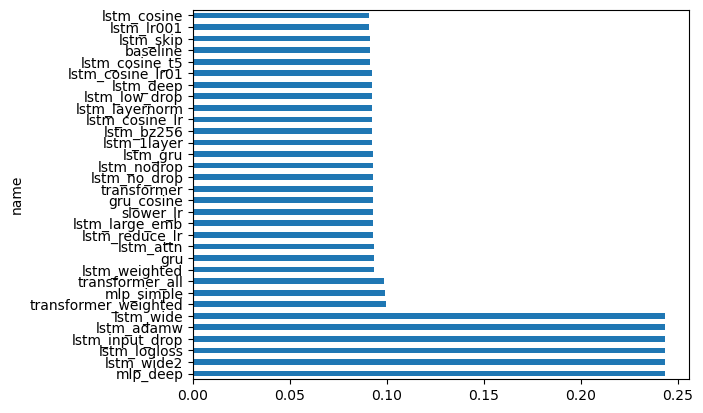

In [4]:
df['best_val_loss'].sort_values(ascending=False).plot(kind='barh')

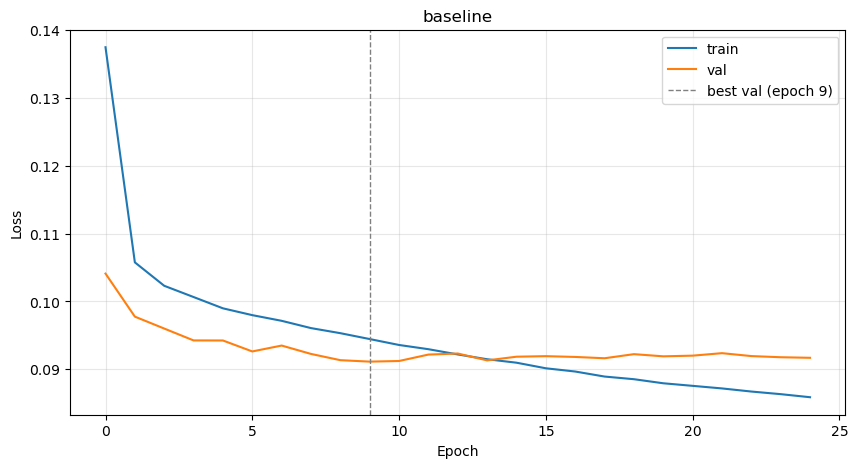

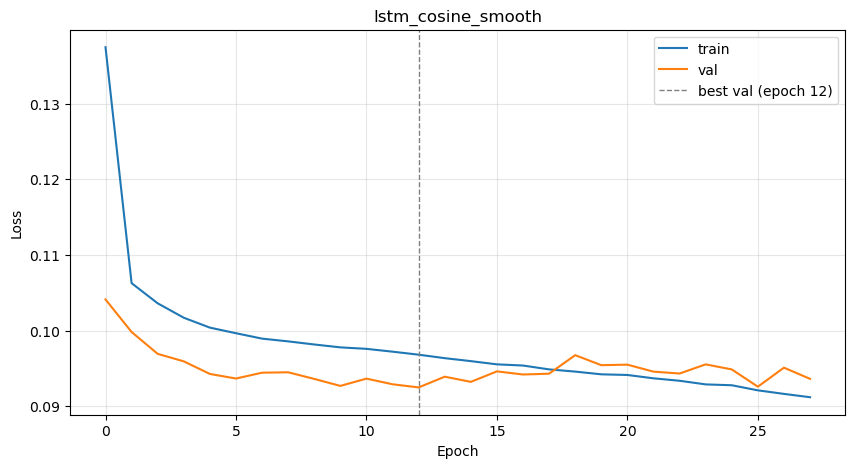

In [19]:
for name in ['baseline', 'lstm_cosine_smooth']:
    ax = plot_curves(d[name])
    ax.set_title(name);